In [ ]:
!pip install pandas numpy requests matplotlib seaborn sqlalchemy pymysql

In [ ]:
import pandas as pd
import numpy as np
import requests
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [ ]:
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

params = {
    "format": "geojson",
    "starttime": "2021-01-01",
    "endtime": "2021-02-01",
    "minmagnitude": 2.5
}

response = requests.get(url, params=params)

print(response.status_code)

200


In [ ]:
import requests
import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta

url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

start_date = datetime(2021, 1, 1)
end_date = datetime(2026, 1, 1)

all_records = []

current_date = start_date

while current_date < end_date:

    next_date = current_date + relativedelta(months=1)

    starttime = current_date.strftime("%Y-%m-%d")
    endtime = next_date.strftime("%Y-%m-%d")

    params = {
        "format": "geojson",
        "starttime": starttime,
        "endtime": endtime,
        "minmagnitude": 2.5
    }

    print("Downloading:", starttime, "to", endtime)

    try:
        response = requests.get(url, params=params, timeout=60)

        if response.status_code == 200:

            data = response.json()

            for feature in data["features"]:

                properties = feature["properties"]
                geometry = feature["geometry"]

                coords = geometry.get("coordinates", [None, None, None])

                record = {
                    "id": feature.get("id"),
                    "time": properties.get("time"),
                    "updated": properties.get("updated"),
                    "latitude": coords[1],
                    "longitude": coords[0],
                    "depth_km": coords[2],
                    "mag": properties.get("mag"),
                    "magType": properties.get("magType"),
                    "place": properties.get("place"),
                    "status": properties.get("status"),
                    "tsunami": properties.get("tsunami"),
                    "sig": properties.get("sig"),
                    "net": properties.get("net"),
                    "nst": properties.get("nst"),
                    "dmin": properties.get("dmin"),
                    "rms": properties.get("rms"),
                    "gap": properties.get("gap"),
                    "magError": properties.get("magError"),
                    "depthError": properties.get("depthError"),
                    "magNst": properties.get("magNst"),
                    "locationSource": properties.get("locationSource"),
                    "magSource": properties.get("magSource"),
                    "types": properties.get("types"),
                    "ids": properties.get("ids"),
                    "sources": properties.get("sources"),
                    "type": properties.get("type")
                }

                all_records.append(record)

        else:
            print("API Error:", response.status_code)

    except Exception as e:
        print("Error:", e)

    current_date = next_date

    time.sleep(0.5)

print("Total records:", len(all_records))

Downloading: 2021-01-01 to 2021-02-01
Downloading: 2021-02-01 to 2021-03-01
Downloading: 2021-03-01 to 2021-04-01
Downloading: 2021-04-01 to 2021-05-01
Downloading: 2021-05-01 to 2021-06-01
Downloading: 2021-06-01 to 2021-07-01
Downloading: 2021-07-01 to 2021-08-01
Downloading: 2021-08-01 to 2021-09-01
Downloading: 2021-09-01 to 2021-10-01
Downloading: 2021-10-01 to 2021-11-01
Downloading: 2021-11-01 to 2021-12-01
Downloading: 2021-12-01 to 2022-01-01
Downloading: 2022-01-01 to 2022-02-01
Downloading: 2022-02-01 to 2022-03-01
Downloading: 2022-03-01 to 2022-04-01
Downloading: 2022-04-01 to 2022-05-01
Downloading: 2022-05-01 to 2022-06-01
Downloading: 2022-06-01 to 2022-07-01
Downloading: 2022-07-01 to 2022-08-01
Downloading: 2022-08-01 to 2022-09-01
Downloading: 2022-09-01 to 2022-10-01
Downloading: 2022-10-01 to 2022-11-01
Downloading: 2022-11-01 to 2022-12-01
Downloading: 2022-12-01 to 2023-01-01
Downloading: 2023-01-01 to 2023-02-01
Downloading: 2023-02-01 to 2023-03-01
Downloading:

In [ ]:
df = pd.DataFrame(all_records)
print(df.shape)


(137465, 26)


In [ ]:
df.head()

,id,time,updated,latitude,longitude,depth_km,mag,magType,place,status,...,gap,magError,depthError,magNst,locationSource,magSource,types,ids,sources,type
0,us6000ddi8,1612135249923,1618599764040,-31.7493,-68.933700,17.27,4.70,mwr,"29 km SW of Villa Basilio Nievas, Argentina",reviewed,...,42.0,None,None,None,None,None,",dyfi,moment-tensor,origin,phase-data,",",us6000ddi8,",",us,",earthquake
1,us6000dev6,1612134497161,1618599827040,-15.4902,-177.205200,426.71,4.10,mb,Fiji region,reviewed,...,64.0,None,None,None,None,None,",origin,phase-data,",",us6000dev6,",",us,",earthquake
2,us6000dev5,1612133659760,1618599827040,19.7529,121.315900,46.73,4.70,mb,"103 km SW of Basco, Philippines",reviewed,...,106.0,None,None,None,None,None,",origin,phase-data,",",us6000dev5,",",us,",earthquake
3,hv72336852,1612131797250,1660012968627,19.2070,-155.500667,35.27,2.68,md,"2 km W of P?hala, Hawaii",reviewed,...,116.0,None,None,None,None,None,",dyfi,origin,phase-data,",",hv72336852,us6000ddhv,",",hv,us,",earthquake
4,us6000ddhs,1612130760832,1618599763040,28.1524,57.257000,10.00,4.90,mb,"114 km N of M?n?b, Iran",reviewed,...,71.0,None,None,None,None,None,",origin,phase-data,",",us6000ddhs,",",us,",earthquake


In [ ]:
df.columns.tolist()

['id',
 'time',
 'updated',
 'latitude',
 'longitude',
 'depth_km',
 'mag',
 'magType',
 'place',
 'status',
 'tsunami',
 'sig',
 'net',
 'nst',
 'dmin',
 'rms',
 'gap',
 'magError',
 'depthError',
 'magNst',
 'locationSource',
 'magSource',
 'types',
 'ids',
 'sources',
 'type']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137465 entries, 0 to 137464
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              137465 non-null  object 
 1   time            137465 non-null  int64  
 2   updated         137465 non-null  int64  
 3   latitude        137465 non-null  float64
 4   longitude       137465 non-null  float64
 5   depth_km        137465 non-null  float64
 6   mag             137465 non-null  float64
 7   magType         137465 non-null  object 
 8   place           137465 non-null  object 
 9   status          137465 non-null  object 
 10  tsunami         137465 non-null  int64  
 11  sig             137465 non-null  int64  
 12  net             137465 non-null  object 
 13  nst             101330 non-null  float64
 14  dmin            125652 non-null  float64
 15  rms             137447 non-null  float64
 16  gap             128880 non-null  float64
 17  magError  

In [ ]:
df.isnull().sum()

,0
id,0
time,0
updated,0
latitude,0
longitude,0
depth_km,0
mag,0
magType,0
place,0
status,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates(subset=["id"])

print(df.shape)

(137465, 26)


In [ ]:
df["time"] = pd.to_datetime(
    df["time"],
    unit="ms",
    errors="coerce"
)

df["updated"] = pd.to_datetime(
    df["updated"],
    unit="ms",
    errors="coerce"
)

In [ ]:
df[["time", "updated"]].head()

,time,updated
0,2021-01-31 23:20:49.923,2021-04-16 19:02:44.040
1,2021-01-31 23:08:17.161,2021-04-16 19:03:47.040
2,2021-01-31 22:54:19.760,2021-04-16 19:03:47.040
3,2021-01-31 22:23:17.250,2022-08-09 02:42:48.627
4,2021-01-31 22:06:00.832,2021-04-16 19:02:43.040


In [ ]:
numeric_columns = [
    "latitude",
    "longitude",
    "depth_km",
    "mag",
    "tsunami",
    "sig",
    "nst",
    "dmin",
    "rms",
    "gap",
    "magError",
    "depthError",
    "magNst"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df["tsunami"] = df["tsunami"].fillna(0).astype(int)

In [ ]:
text_columns = [
    "magType",
    "place",
    "status",
    "net",
    "locationSource",
    "magSource",
    "types",
    "ids",
    "sources",
    "type"
]

for col in text_columns:
    df[col] = df[col].fillna("Unknown")
    df[col] = df[col].astype(str).str.strip()

In [ ]:
def extract_country(place):

    if pd.isna(place):
        return "Unknown"

    match = re.search(r",\s*([^,]+)$", str(place))

    if match:
        return match.group(1).strip()

    return "Unknown"

In [ ]:
df["country"] = df["place"].apply(extract_country)

In [ ]:
df[["place", "country"]].head(20)

,place,country
0,"29 km SW of Villa Basilio Nievas, Argentina",Argentina
1,Fiji region,Unknown
2,"103 km SW of Basco, Philippines",Philippines
3,"2 km W of P?hala, Hawaii",Hawaii
4,"114 km N of M?n?b, Iran",Iran
5,"184 km ENE of Olonkinbyen, Svalbard and Jan Mayen",Svalbard and Jan Mayen
6,"76 km NNE of Luquillo, Puerto Rico",Puerto Rico
7,"78 km NNE of Luquillo, Puerto Rico",Puerto Rico
8,"82 km N of Culebra, Puerto Rico",Puerto Rico
9,"99 km SE of Pondaguitan, Philippines",Philippines


In [ ]:
df["year"] = df["time"].dt.year

In [ ]:
df["month"] = df["time"].dt.month

In [ ]:
df["month_name"] = df["time"].dt.month_name()

In [ ]:
df["day"] = df["time"].dt.day

In [ ]:
df["day_of_week"] = df["time"].dt.day_name()

In [ ]:
df["hour"] = df["time"].dt.hour

In [ ]:
def depth_category(depth):

    if depth < 50:
        return "Shallow"

    elif depth <= 300:
        return "Intermediate"

    else:
        return "Deep"

In [ ]:
df["depth_category"] = df["depth_km"].apply(depth_category)

In [ ]:
def magnitude_category(mag):

    if mag >= 7.0:
        return "Major"

    elif mag >= 6.0:
        return "Strong"

    elif mag >= 5.0:
        return "Moderate"

    else:
        return "Minor"

In [ ]:
df["magnitude_category"] = df["mag"].apply(magnitude_category)

In [ ]:
df["tsunami_flag"] = df["tsunami"].apply(
    lambda x: "Yes" if x == 1 else "No"
)

In [ ]:
df["alert"] = "Unknown"

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 137465
Columns: 37


In [ ]:
df.head()

,id,time,updated,latitude,longitude,depth_km,mag,magType,place,status,...,year,month,month_name,day,day_of_week,hour,depth_category,magnitude_category,tsunami_flag,alert
0,us6000ddi8,2021-01-31 23:20:49.923,2021-04-16 19:02:44.040,-31.7493,-68.933700,17.27,4.70,mwr,"29 km SW of Villa Basilio Nievas, Argentina",reviewed,...,2021,1,January,31,Sunday,23,Shallow,Minor,No,Unknown
1,us6000dev6,2021-01-31 23:08:17.161,2021-04-16 19:03:47.040,-15.4902,-177.205200,426.71,4.10,mb,Fiji region,reviewed,...,2021,1,January,31,Sunday,23,Deep,Minor,No,Unknown
2,us6000dev5,2021-01-31 22:54:19.760,2021-04-16 19:03:47.040,19.7529,121.315900,46.73,4.70,mb,"103 km SW of Basco, Philippines",reviewed,...,2021,1,January,31,Sunday,22,Shallow,Minor,No,Unknown
3,hv72336852,2021-01-31 22:23:17.250,2022-08-09 02:42:48.627,19.2070,-155.500667,35.27,2.68,md,"2 km W of P?hala, Hawaii",reviewed,...,2021,1,January,31,Sunday,22,Shallow,Minor,No,Unknown
4,us6000ddhs,2021-01-31 22:06:00.832,2021-04-16 19:02:43.040,28.1524,57.257000,10.00,4.90,mb,"114 km N of M?n?b, Iran",reviewed,...,2021,1,January,31,Sunday,22,Shallow,Minor,No,Unknown


In [ ]:
for i, col in enumerate(df.columns, 1):
    print(i, col)

1 id
2 time
3 updated
4 latitude
5 longitude
6 depth_km
7 mag
8 magType
9 place
10 status
11 tsunami
12 sig
13 net
14 nst
15 dmin
16 rms
17 gap
18 magError
19 depthError
20 magNst
21 locationSource
22 magSource
23 types
24 ids
25 sources
26 type
27 country
28 year
29 month
30 month_name
31 day
32 day_of_week
33 hour
34 depth_category
35 magnitude_category
36 tsunami_flag
37 alert


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Duplicate rows: 0

Missing values:
id                         0
time                       0
updated                    0
latitude                   0
longitude                  0
depth_km                   0
mag                        0
magType                    0
place                      0
status                     0
tsunami                    0
sig                        0
net                        0
nst                        0
dmin                       0
rms                        0
gap                        0
magError              137465
depthError            137465
magNst                137465
locationSource             0
magSource                  0
types                      0
ids                        0
sources                    0
type                       0
country                    0
year                       0
month                      0
month_name                 0
day                        0
day_of_week                0
hour                       0
depth_ca

In [ ]:
top_10_strongest = df.nlargest(10, "mag")

top_10_strongest[
    ["id", "time", "place", "country", "mag", "depth_km"]
]

,id,time,place,country,mag,depth_km
122174,us6000qw60,2025-07-29 23:24:52.483,"2025 Kamchatka Peninsula, Russia Earthquake",Russia Earthquake,8.8,35.000
14493,ak0219neiszm,2021-07-29 06:15:49.188,"2021 Chignik, Alaska Earthquake",Alaska Earthquake,8.2,35.000
7368,us7000dflf,2021-03-04 19:28:33.178,"2021 Kermadec Islands, New Zealand Earthquake",New Zealand Earthquake,8.1,28.930
18941,us6000f53e,2021-08-12 18:35:17.231,2021 South Sandwich Islands Earthquake,Unknown,8.1,22.790
60098,us6000jllz,2023-02-06 01:17:34.342,"Pazarcik earthquake, Kahramanmaras earthquake ...",Kahramanmaras earthquake sequence,7.8,10.000
129379,us7000qx2g,2025-09-18 18:58:14.939,"140 km E of Petropavlovsk-Kamchatsky, Russia",Russia,7.8,27.000
4073,us6000dg77,2021-02-10 13:19:55.530,southeast of the Loyalty Islands,Unknown,7.7,10.000
65920,us6000kd0n,2023-05-19 02:57:03.172,southeast of the Loyalty Islands,Unknown,7.7,18.053
112980,us7000pn9s,2025-03-28 06:20:52.715,"2025 Mandalay, Burma (Myanmar) Earthquake",Burma (Myanmar) Earthquake,7.7,10.000
47921,us7000i9bw,2022-09-19 18:05:08.217,"35 km SSW of Aguililla, Mexico",Mexico,7.6,26.943


In [ ]:
top_10_deepest = df.nlargest(10, "depth_km")

top_10_deepest[
    ["id", "time", "place", "country", "mag", "depth_km"]
]

,id,time,place,country,mag,depth_km
64749,us6000k2db,2023-04-01 18:09:17.114,"208 km ENE of Sola, Vanuatu",Vanuatu,4.0,681.238
74344,us7000kxdn,2023-09-18 15:35:27.270,Vanuatu region,Unknown,4.2,675.265
88888,us6000mivr,2024-03-08 22:42:23.713,Fiji region,Unknown,4.2,671.043
130736,us6000rk66,2025-10-29 17:07:34.157,"205 km ESE of Levuka, Fiji",Fiji,4.8,669.556
19905,us6000f2w3,2021-08-01 22:12:46.340,"283 km SE of Levuka, Fiji",Fiji,4.0,669.460
118455,us7000q1jk,2025-05-10 02:03:16.756,"299 km E of Levuka, Fiji",Fiji,4.2,667.237
3609,us6000dhfx,2021-02-13 16:26:42.487,south of the Fiji Islands,Unknown,4.5,664.740
42216,us7000he64,2022-06-01 18:41:01.389,"279 km ESE of Labasa, Fiji",Fiji,4.3,664.700
80148,us6000m2wg,2023-12-31 02:19:26.839,"138 km NE of Sola, Vanuatu",Vanuatu,4.1,660.826
53144,us7000ingi,2022-11-09 09:51:04.068,south of the Fiji Islands,Unknown,7.0,660.000


In [ ]:
shallow_strong = df[
    (df["depth_km"] < 50) &
    (df["mag"] > 7.5)
]

shallow_strong[
    ["time", "place", "country", "mag", "depth_km"]
]

,time,place,country,mag,depth_km
4073,2021-02-10 13:19:55.530,southeast of the Loyalty Islands,Unknown,7.7,10.000
7368,2021-03-04 19:28:33.178,"2021 Kermadec Islands, New Zealand Earthquake",New Zealand Earthquake,8.1,28.930
14493,2021-07-29 06:15:49.188,"2021 Chignik, Alaska Earthquake",Alaska Earthquake,8.2,35.000
18941,2021-08-12 18:35:17.231,2021 South Sandwich Islands Earthquake,Unknown,8.1,22.790
47921,2022-09-19 18:05:08.217,"35 km SSW of Aguililla, Mexico",Mexico,7.6,26.943
60098,2023-02-06 01:17:34.342,"Pazarcik earthquake, Kahramanmaras earthquake ...",Kahramanmaras earthquake sequence,7.8,10.000
65920,2023-05-19 02:57:03.172,southeast of the Loyalty Islands,Unknown,7.7,18.053
82982,2023-12-02 14:37:04.454,"19 km E of Gamut, Philippines",Philippines,7.6,40.000
111976,2025-02-08 23:23:14.697,"210 km SSW of George Town, Cayman Islands",Cayman Islands,7.6,14.326
112980,2025-03-28 06:20:52.715,"2025 Mandalay, Burma (Myanmar) Earthquake",Burma (Myanmar) Earthquake,7.7,10.000


In [ ]:
year_count = (
    df.groupby("year")
      .size()
      .reset_index(name="earthquake_count")
      .sort_values("earthquake_count", ascending=False)
)

year_count

,year,earthquake_count
4,2025,29204
0,2021,28896
2,2023,27301
1,2022,26911
3,2024,25153


In [ ]:
month_count = (
    df.groupby("month_name")
      .size()
      .reset_index(name="earthquake_count")
      .sort_values("earthquake_count", ascending=False)
)

month_count

,month_name,earthquake_count
5,July,13272
2,December,13139
1,August,12902
4,January,11812
7,March,11781
3,February,11113
0,April,10763
11,September,10707
8,May,10642
10,October,10600


In [ ]:
weekday_count = (
    df.groupby("day_of_week")
      .size()
      .reset_index(name="earthquake_count")
      .sort_values("earthquake_count", ascending=False)
)

weekday_count

,day_of_week,earthquake_count
0,Friday,19833
3,Sunday,19814
5,Tuesday,19758
4,Thursday,19565
2,Saturday,19536
6,Wednesday,19487
1,Monday,19472


In [ ]:
hour_count = (
    df.groupby("hour")
      .size()
      .reset_index(name="earthquake_count")
)

hour_count

,hour,earthquake_count
0,0,5688
1,1,5995
2,2,5796
3,3,6102
4,4,6110
5,5,5676
6,6,5578
7,7,5771
8,8,5743
9,9,5722


In [ ]:
hour_count = (
    df.groupby("hour")
      .size()
      .reset_index(name="earthquake_count")
)

hour_count

,hour,earthquake_count
0,0,5688
1,1,5995
2,2,5796
3,3,6102
4,4,6110
5,5,5676
6,6,5578
7,7,5771
8,8,5743
9,9,5722


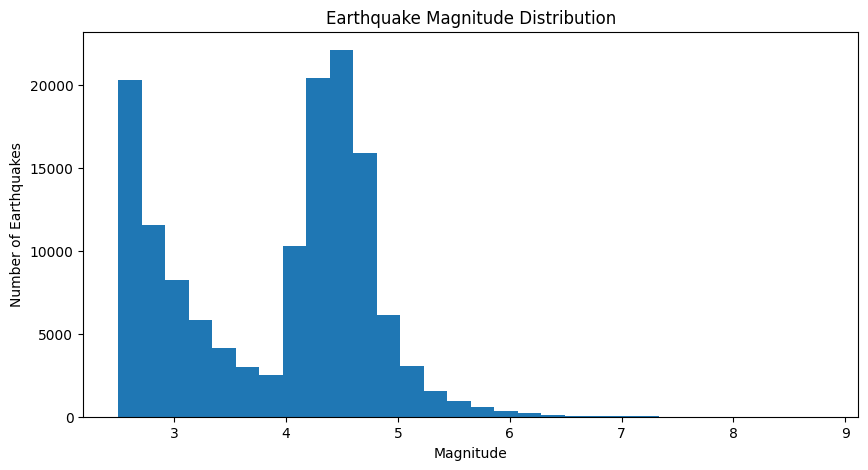

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["mag"], bins=30)

plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquake Magnitude Distribution")

plt.show()

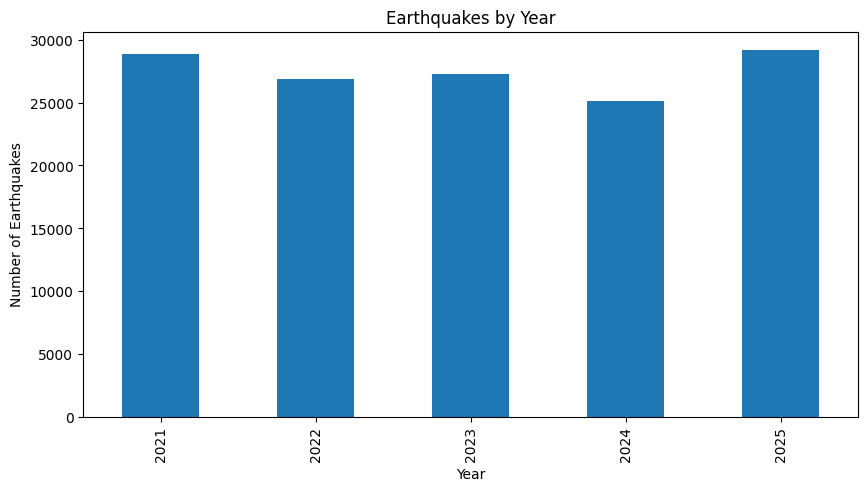

In [ ]:
plt.figure(figsize=(10, 5))

year_count = df.groupby("year").size()

year_count.plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquakes by Year")

plt.show()

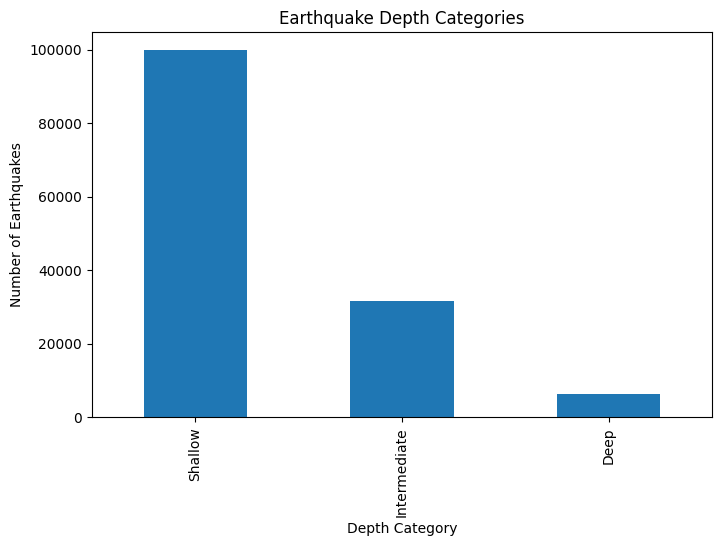

In [ ]:
depth_counts = df["depth_category"].value_counts()

plt.figure(figsize=(8, 5))

depth_counts.plot(kind="bar")

plt.xlabel("Depth Category")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquake Depth Categories")

plt.show()

In [ ]:
df

,id,time,updated,latitude,longitude,depth_km,mag,magType,place,status,...,year,month,month_name,day,day_of_week,hour,depth_category,magnitude_category,tsunami_flag,alert
0,us6000ddi8,2021-01-31 23:20:49.923,2021-04-16 19:02:44.040,-31.7493,-68.933700,17.270,4.70,mwr,"29 km SW of Villa Basilio Nievas, Argentina",reviewed,...,2021,1,January,31,Sunday,23,Shallow,Minor,No,Unknown
1,us6000dev6,2021-01-31 23:08:17.161,2021-04-16 19:03:47.040,-15.4902,-177.205200,426.710,4.10,mb,Fiji region,reviewed,...,2021,1,January,31,Sunday,23,Deep,Minor,No,Unknown
2,us6000dev5,2021-01-31 22:54:19.760,2021-04-16 19:03:47.040,19.7529,121.315900,46.730,4.70,mb,"103 km SW of Basco, Philippines",reviewed,...,2021,1,January,31,Sunday,22,Shallow,Minor,No,Unknown
3,hv72336852,2021-01-31 22:23:17.250,2022-08-09 02:42:48.627,19.2070,-155.500667,35.270,2.68,md,"2 km W of P?hala, Hawaii",reviewed,...,2021,1,January,31,Sunday,22,Shallow,Minor,No,Unknown
4,us6000ddhs,2021-01-31 22:06:00.832,2021-04-16 19:02:43.040,28.1524,57.257000,10.000,4.90,mb,"114 km N of M?n?b, Iran",reviewed,...,2021,1,January,31,Sunday,22,Shallow,Minor,No,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137460,ak2025xpgfse,2025-12-01 01:51:06.974,2026-02-25 16:18:40.040,59.1380,-150.640000,15.200,3.20,ml,"60 km SSE of Halibut Cove, Alaska",reviewed,...,2025,12,December,1,Monday,1,Shallow,Minor,No,Unknown
137461,us7000ret3,2025-12-01 01:41:43.796,2026-02-25 16:18:40.040,7.4127,127.070400,35.000,4.60,mb,"53 km E of Baculin, Philippines",reviewed,...,2025,12,December,1,Monday,1,Shallow,Minor,No,Unknown
137462,us7000ret2,2025-12-01 01:37:57.834,2026-02-25 16:18:40.040,-19.4176,-67.276100,227.844,4.10,mb,"78 km SW of Challapata, Bolivia",reviewed,...,2025,12,December,1,Monday,1,Intermediate,Minor,No,Unknown
137463,us7000resz,2025-12-01 01:25:46.725,2026-02-25 16:18:40.040,47.3283,-113.201900,30.159,3.10,ml,"27 km NE of Seeley Lake, Montana",reviewed,...,2025,12,December,1,Monday,1,Shallow,Minor,No,Unknown


In [ ]:
df.to_csv(
    "earthquake_cleaned.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("earthquake_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 64.7 MB/s eta 0:00:00


In [ ]:
import mysql.connector

conn = mysql.connector.connect(
    host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
    port=4000,
    user="2ow7fzo5mRAMRmu.root",
    password="VORWif0dPOWA4Uuh",
    database="seismic_db"
)

print("Connected to TiDB successfully!")

Connected to TiDB successfully!


In [ ]:
cursor = conn.cursor()

cursor.execute("SHOW TABLES")

for table in cursor.fetchall():
    print(table[0])

earthquakes


In [ ]:
cursor.execute("SELECT * FROM earthquakes")

for row in cursor.fetchall():
    print(row)

In [ ]:
pip install streamlit pymysql

In [ ]:
%%writefile /content/app.py
import streamlit as st
import pymysql
import pandas as pd
import plotly.express as px

# Database connection
connection = pymysql.connect(
    host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
    port=4000,
    user="2ow7fzo5mRAMRmu.root",
    password="VORWif0dPOWA4Uuh",
    database="seismic_db",
    ssl={"ssl": {}}
)



# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Global Earthquake Analytics",
    page_icon="🌍",
    layout="wide"
)


# =========================================================
# TITLE
# =========================================================

st.title("🌍 Global Earthquake Analytics Dashboard")

st.write(
    "Analysis of global earthquake data using USGS API, "
    "Python, Pandas, SQL and TiDB."
)


# =========================================================
# DATABASE CONNECTION
# =========================================================

@st.cache_resource
def get_connection():

    return pymysql.connect(
        host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
        port=4000,
        user="2ow7fzo5mRAMRmu.root",
        password="VORWif0dPOWA4Uuh",
        database="seismic_db",
        ssl={}
    )


# =========================================================
# LOAD DATA
# =========================================================

@st.cache_data(ttl=600)
def load_data():

    connection = get_connection()

    query = "SELECT * FROM earthquakes"

    df = pd.read_sql(query, connection)

    return df


# =========================================================
# CONNECT TO DATABASE
# =========================================================

try:

    df = load_data()

    st.success(
        f"✅ TiDB Connected Successfully | "
        f"{len(df):,} earthquake records loaded"
    )

except Exception as e:

    st.error(f"❌ Database connection failed: {e}")

    st.stop()


# =========================================================
# CHECK DATA
# =========================================================

if df.empty:

    st.warning("⚠️ No earthquake records found in the database.")

    st.stop()


# =========================================================
# DATA PREPARATION
# =========================================================

if "time" in df.columns:

    df["time"] = pd.to_datetime(
        df["time"],
        errors="coerce"
    )


if "updated" in df.columns:

    df["updated"] = pd.to_datetime(
        df["updated"],
        errors="coerce"
    )


numeric_columns = [
    "mag",
    "depth_km",
    "latitude",
    "longitude",
    "sig",
    "nst",
    "dmin",
    "rms",
    "gap",
    "magError",
    "depthError",
    "magNst",
    "tsunami"
]


for column in numeric_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.header("🔎 Filters")


# =========================================================
# MAGNITUDE FILTER
# =========================================================

if "mag" in df.columns:

    valid_mag = df["mag"].dropna()

    if not valid_mag.empty:

        min_mag = float(valid_mag.min())
        max_mag = float(valid_mag.max())

        if min_mag < max_mag:

            magnitude_range = st.sidebar.slider(
                "Magnitude",
                min_value=min_mag,
                max_value=max_mag,
                value=(min_mag, max_mag),
                step=0.1
            )

        else:

            magnitude_range = (min_mag, max_mag)

    else:

        magnitude_range = None

else:

    magnitude_range = None


# =========================================================
# DEPTH FILTER
# =========================================================

if "depth_km" in df.columns:

    valid_depth = df["depth_km"].dropna()

    if not valid_depth.empty:

        min_depth = float(valid_depth.min())
        max_depth = float(valid_depth.max())

        if min_depth < max_depth:

            depth_range = st.sidebar.slider(
                "Depth (km)",
                min_value=min_depth,
                max_value=max_depth,
                value=(min_depth, max_depth)
            )

        else:

            depth_range = (min_depth, max_depth)

    else:

        depth_range = None

else:

    depth_range = None


# =========================================================
# STATUS FILTER
# =========================================================

if "status" in df.columns:

    status_list = (
        df["status"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    selected_status = st.sidebar.multiselect(
        "Status",
        status_list,
        default=status_list
    )

else:

    selected_status = []


# =========================================================
# MAGNITUDE TYPE FILTER
# =========================================================

if "magType" in df.columns:

    magtype_list = (
        df["magType"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    selected_magtype = st.sidebar.multiselect(
        "Magnitude Type",
        magtype_list,
        default=magtype_list
    )

else:

    selected_magtype = []


# =========================================================
# APPLY FILTERS
# =========================================================

filtered_df = df.copy()


# Magnitude

if magnitude_range is not None:

    filtered_df = filtered_df[
        (filtered_df["mag"] >= magnitude_range[0])
        &
        (filtered_df["mag"] <= magnitude_range[1])
    ]


# Depth

if depth_range is not None:

    filtered_df = filtered_df[
        (filtered_df["depth_km"] >= depth_range[0])
        &
        (filtered_df["depth_km"] <= depth_range[1])
    ]


# Status

if "status" in filtered_df.columns:

    if selected_status:

        filtered_df = filtered_df[
            filtered_df["status"]
            .astype(str)
            .isin(selected_status)
        ]


# Magnitude Type

if "magType" in filtered_df.columns:

    if selected_magtype:

        filtered_df = filtered_df[
            filtered_df["magType"]
            .astype(str)
            .isin(selected_magtype)
        ]


# =========================================================
# KPI SECTION
# =========================================================

st.header("📊 Earthquake Overview")

col1, col2, col3, col4, col5 = st.columns(5)


# =========================================================
# TOTAL EARTHQUAKES
# =========================================================

with col1:

    st.metric(
        "🌋 Total Earthquakes",
        f"{len(filtered_df):,}"
    )


# =========================================================
# AVERAGE MAGNITUDE
# =========================================================

with col2:

    if "mag" in filtered_df.columns:

        average_mag = filtered_df["mag"].mean()

        if pd.notna(average_mag):

            st.metric(
                "📈 Average Magnitude",
                f"{average_mag:.2f}"
            )

        else:

            st.metric(
                "📈 Average Magnitude",
                "N/A"
            )


# =========================================================
# MAXIMUM MAGNITUDE
# =========================================================

with col3:

    if "mag" in filtered_df.columns:

        maximum_mag = filtered_df["mag"].max()

        if pd.notna(maximum_mag):

            st.metric(
                "💥 Maximum Magnitude",
                f"{maximum_mag:.2f}"
            )

        else:

            st.metric(
                "💥 Maximum Magnitude",
                "N/A"
            )


# =========================================================
# AVERAGE DEPTH
# =========================================================

with col4:

    if "depth_km" in filtered_df.columns:

        average_depth = filtered_df["depth_km"].mean()

        if pd.notna(average_depth):

            st.metric(
                "⬇️ Average Depth",
                f"{average_depth:.2f} km"
            )

        else:

            st.metric(
                "⬇️ Average Depth",
                "N/A"
            )


# =========================================================
# TSUNAMI
# =========================================================

with col5:

    if "tsunami" in filtered_df.columns:

        tsunami_count = (
            filtered_df["tsunami"]
            .fillna(0)
            .astype(int)
            .sum()
        )

        st.metric(
            "🌊 Tsunami Events",
            f"{tsunami_count:,}"
        )


# =========================================================
# MAP
# =========================================================

st.header("🗺️ Global Earthquake Locations")

if all(
    column in filtered_df.columns
    for column in ["latitude", "longitude"]
):

    map_data = filtered_df[
        ["latitude", "longitude"]
    ].dropna()

    if not map_data.empty:

        st.map(map_data)

    else:

        st.warning(
            "⚠️ No valid latitude/longitude data available."
        )

else:

    st.warning(
        "⚠️ Latitude and longitude columns are missing."
    )


# =========================================================
# YEARLY TREND
# =========================================================

st.header("📈 Earthquake Trend by Year")

if "time" in filtered_df.columns:

    yearly_data = (
        filtered_df
        .dropna(subset=["time"])
        .assign(
            year=lambda x: x["time"].dt.year
        )
        .groupby("year")
        .size()
        .reset_index(
            name="earthquake_count"
        )
    )

    if not yearly_data.empty:

        fig_year = px.line(
            yearly_data,
            x="year",
            y="earthquake_count",
            markers=True,
            title="Earthquakes per Year"
        )

        st.plotly_chart(
            fig_year,
            use_container_width=True
        )


# =========================================================
# MONTHLY TREND
# =========================================================

st.header("📅 Earthquake Activity by Month")

if "time" in filtered_df.columns:

    monthly_data = (
        filtered_df
        .dropna(subset=["time"])
        .assign(
            month=lambda x: x["time"].dt.month
        )
        .groupby("month")
        .size()
        .reset_index(
            name="earthquake_count"
        )
    )

    month_names = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December"
    }

    monthly_data["month_name"] = (
        monthly_data["month"]
        .map(month_names)
    )

    monthly_data = monthly_data.sort_values("month")

    if not monthly_data.empty:

        fig_month = px.bar(
            monthly_data,
            x="month_name",
            y="earthquake_count",
            title="Earthquakes by Month"
        )

        st.plotly_chart(
            fig_month,
            use_container_width=True
        )


# =========================================================
# MAGNITUDE & DEPTH
# =========================================================

col1, col2 = st.columns(2)


# =========================================================
# MAGNITUDE DISTRIBUTION
# =========================================================

with col1:

    st.subheader("💥 Magnitude Distribution")

    if "mag" in filtered_df.columns:

        magnitude_data = filtered_df.dropna(
            subset=["mag"]
        )

        if not magnitude_data.empty:

            fig_mag = px.histogram(
                magnitude_data,
                x="mag",
                nbins=30,
                title="Magnitude Distribution"
            )

            st.plotly_chart(
                fig_mag,
                use_container_width=True
            )


# =========================================================
# DEPTH DISTRIBUTION
# =========================================================

with col2:

    st.subheader("⬇️ Depth Distribution")

    if "depth_km" in filtered_df.columns:

        depth_data_plot = filtered_df.dropna(
            subset=["depth_km"]
        )

        if not depth_data_plot.empty:

            fig_depth = px.histogram(
                depth_data_plot,
                x="depth_km",
                nbins=30,
                title="Depth Distribution"
            )

            st.plotly_chart(
                fig_depth,
                use_container_width=True
            )


# =========================================================
# MAGNITUDE TYPE
# =========================================================

st.header("📊 Average Magnitude by Magnitude Type")

if (
    "magType" in filtered_df.columns
    and "mag" in filtered_df.columns
):

    magtype_data = (
        filtered_df
        .dropna(subset=["magType", "mag"])
        .groupby("magType")["mag"]
        .agg(["mean", "count"])
        .reset_index()
    )

    magtype_data.columns = [
        "magType",
        "average_magnitude",
        "count"
    ]

    if not magtype_data.empty:

        fig_magtype = px.bar(
            magtype_data,
            x="magType",
            y="average_magnitude",
            hover_data=["count"],
            title="Average Magnitude by magType"
        )

        st.plotly_chart(
            fig_magtype,
            use_container_width=True
        )


# =========================================================
# DEPTH CATEGORY
# =========================================================

st.header("🌋 Earthquake Depth Categories")


if "depth_km" in filtered_df.columns:

    def classify_depth(depth):

        if pd.isna(depth):

            return "Unknown"

        if depth < 50:

            return "Shallow (<50 km)"

        elif depth < 300:

            return "Intermediate (50–300 km)"

        else:

            return "Deep (>300 km)"


    filtered_df = filtered_df.copy()

    filtered_df["depth_category_dashboard"] = (
        filtered_df["depth_km"]
        .apply(classify_depth)
    )


    depth_data = (
        filtered_df["depth_category_dashboard"]
        .value_counts()
        .reset_index()
    )


    depth_data.columns = [
        "depth_category",
        "count"
    ]


    if not depth_data.empty:

        fig_depth_category = px.pie(
            depth_data,
            names="depth_category",
            values="count",
            title="Earthquake Depth Categories"
        )


        st.plotly_chart(
            fig_depth_category,
            use_container_width=True
        )


# =========================================================
# TSUNAMI ANALYSIS
# =========================================================

st.header("🌊 Tsunami Analysis")

if "tsunami" in filtered_df.columns:

    tsunami_data = (
        filtered_df["tsunami"]
        .fillna(0)
        .astype(int)
        .value_counts()
        .reset_index()
    )

    tsunami_data.columns = [
        "tsunami",
        "count"
    ]

    tsunami_data["label"] = (
        tsunami_data["tsunami"]
        .map({
            0: "No Tsunami",
            1: "Tsunami"
        })
        .fillna("Other")
    )

    if not tsunami_data.empty:

        fig_tsunami = px.pie(
            tsunami_data,
            names="label",
            values="count",
            title="Tsunami vs Non-Tsunami"
        )

        st.plotly_chart(
            fig_tsunami,
            use_container_width=True
        )


# =========================================================
# STATUS & REPORTING NETWORK
# =========================================================

col1, col2 = st.columns(2)


# =========================================================
# STATUS
# =========================================================

with col1:

    st.subheader("✅ Reviewed vs Automatic")

    if "status" in filtered_df.columns:

        status_data = (
            filtered_df["status"]
            .value_counts()
            .reset_index()
        )

        status_data.columns = [
            "status",
            "count"
        ]

        if not status_data.empty:

            fig_status = px.bar(
                status_data,
                x="status",
                y="count",
                title="Earthquake Status"
            )

            st.plotly_chart(
                fig_status,
                use_container_width=True
            )


# =========================================================
# REPORTING NETWORK
# =========================================================

with col2:

    st.subheader("🌐 Top Reporting Networks")

    if "net" in filtered_df.columns:

        network_data = (
            filtered_df["net"]
            .value_counts()
            .head(10)
            .reset_index()
        )

        network_data.columns = [
            "network",
            "count"
        ]

        if not network_data.empty:

            fig_network = px.bar(
                network_data,
                x="network",
                y="count",
                title="Top 10 Reporting Networks"
            )

            st.plotly_chart(
                fig_network,
                use_container_width=True
            )


# =========================================================
# TOP 10 STRONGEST EARTHQUAKES
# =========================================================

st.header("💥 Top 10 Strongest Earthquakes")

if "mag" in filtered_df.columns:

    strongest = (
        filtered_df
        .dropna(subset=["mag"])
        .sort_values(
            "mag",
            ascending=False
        )
        .head(10)
    )

    display_columns = [
        column
        for column in [
            "time",
            "place",
            "mag",
            "depth_km",
            "status",
            "tsunami"
        ]
        if column in strongest.columns
    ]

    st.dataframe(
        strongest[display_columns],
        use_container_width=True,
        hide_index=True
    )


# =========================================================
# TOP 10 DEEPEST
# =========================================================

st.header("⬇️ Top 10 Deepest Earthquakes")

if "depth_km" in filtered_df.columns:

    deepest = (
        filtered_df
        .dropna(subset=["depth_km"])
        .sort_values(
            "depth_km",
            ascending=False
        )
        .head(10)
    )

    display_columns = [
        column
        for column in [
            "time",
            "place",
            "mag",
            "depth_km",
            "status"
        ]
        if column in deepest.columns
    ]

    st.dataframe(
        deepest[display_columns],
        use_container_width=True,
        hide_index=True
    )


# =========================================================
# STRONG SHALLOW EARTHQUAKES
# =========================================================

st.header("⚠️ Strong Shallow Earthquakes")

if all(
    column in filtered_df.columns
    for column in ["mag", "depth_km"]
):

    strong_shallow = filtered_df[
        (filtered_df["depth_km"] < 50)
        &
        (filtered_df["mag"] > 7.5)
    ]

    st.metric(
        "Magnitude > 7.5 & Depth < 50 km",
        f"{len(strong_shallow):,}"
    )

    display_columns = [
        column
        for column in [
            "time",
            "place",
            "mag",
            "depth_km",
            "tsunami",
            "status"
        ]
        if column in strong_shallow.columns
    ]

    st.dataframe(
        strong_shallow[display_columns],
        use_container_width=True,
        hide_index=True
    )


# =========================================================
# DATA QUALITY
# =========================================================

st.header("🔍 Data Quality Metrics")

col1, col2, col3 = st.columns(3)


# High station coverage

with col1:

    if "nst" in filtered_df.columns:

        high_station = (
            filtered_df["nst"] > 20
        ).sum()

        st.metric(
            "High Station Coverage",
            f"{high_station:,}"
        )


# Average gap

with col2:

    if "gap" in filtered_df.columns:

        average_gap = filtered_df["gap"].mean()

        if pd.notna(average_gap):

            st.metric(
                "Average Gap",
                f"{average_gap:.2f}"
            )

        else:

            st.metric(
                "Average Gap",
                "N/A"
            )


# Average RMS

with col3:

    if "rms" in filtered_df.columns:

        average_rms = filtered_df["rms"].mean()

        if pd.notna(average_rms):

            st.metric(
                "Average RMS",
                f"{average_rms:.3f}"
            )

        else:

            st.metric(
                "Average RMS",
                "N/A"
            )


# =========================================================
# COUNTRY ANALYSIS
# =========================================================

if "country" in filtered_df.columns:

    st.header("🌎 Top Countries by Earthquake Frequency")

    country_data = (
        filtered_df["country"]
        .dropna()
        .value_counts()
        .head(15)
        .reset_index()
    )

    country_data.columns = [
        "country",
        "earthquake_count"
    ]

    if not country_data.empty:

        fig_country = px.bar(
            country_data,
            x="earthquake_count",
            y="country",
            orientation="h",
            title="Top 15 Countries"
        )

        st.plotly_chart(
            fig_country,
            use_container_width=True
        )


# =========================================================
# DATA TABLE
# =========================================================

st.header("📋 Earthquake Dataset")

st.write(
    f"Showing {len(filtered_df):,} filtered records"
)

st.dataframe(
    filtered_df,
    use_container_width=True,
    height=500
)


# =========================================================
# DOWNLOAD
# =========================================================

csv_data = (
    filtered_df
    .to_csv(index=False)
    .encode("utf-8")
)


st.download_button(
    "⬇️ Download Filtered Dataset",
    data=csv_data,
    file_name="earthquake_filtered_data.csv",
    mime="text/csv"
)


# =========================================================
# FOOTER
# =========================================================

st.markdown("---")

st.caption(
    "Global Earthquake Analytics | "
    "USGS API | Python | Pandas | MySQL/TiDB | "
    "SQL | Streamlit"
)

In [ ]:
!pip install streamlit pymysql pyngrok

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("Streamlit URL:", public_url)

Streamlit URL: NgrokTunnel: "https://chirping-verbalize-cymbal.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pip install streamlit pymysql pyngrok -q

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3HiWvBFhqGV7lOSLWzJKhe7N8rj_6G11MBqzcoHL6KEz4KTM8")

print("ngrok authentication successful")